<a href="https://colab.research.google.com/github/tylerlherzog/AIHC-5010-Winter-2026/blob/main/AIHC5010_Homework1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 1:
Create a Jupyter Notebook that implements a
perceptron and trains the model on an
example dataset

In [7]:
import numpy as np
import matplotlib.pyplot as plt

Dataset 1: A linearly seperable dataset

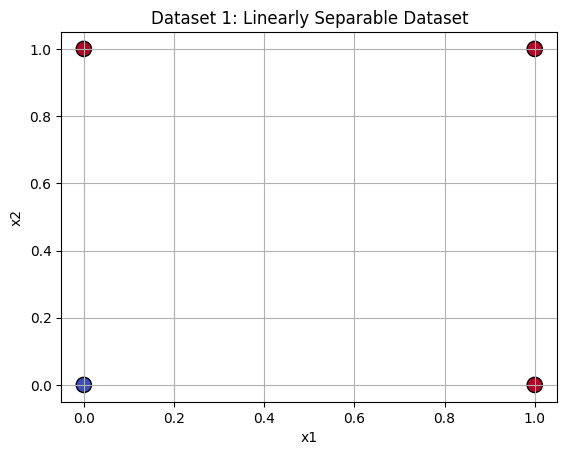

In [8]:
# Create the dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([-1, 1, 1, 1])

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=120, edgecolors="k")
plt.title("Dataset 1: Linearly Separable Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

Converged at epoch 6
Weights: [2. 2.]
Bias: -1.0
Training accuracy: 1.0


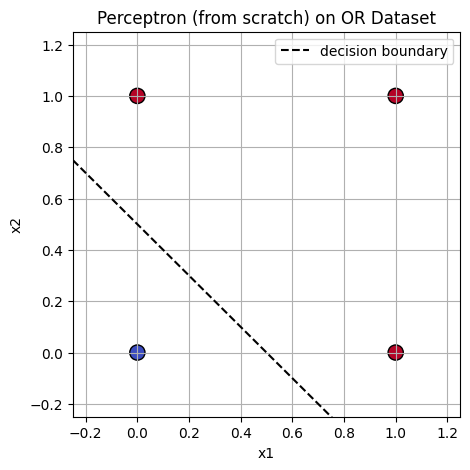

In [9]:
# Initialize
w = np.zeros(2)
b = 0.0
lr = 1.0
max_epochs = 100

def predict_sign(x):
    return 1 if (np.dot(w, x) + b) >= 0 else -1

# Training loop
for epoch in range(max_epochs):
    errors = 0
    for xi, yi in zip(X, y):
        y_hat = predict_sign(xi)
        if yi * (np.dot(w, xi) + b) <= 0:
            # Misclassified → update
            w += lr * yi * xi
            b += lr * yi
            errors += 1
    if errors == 0:  # converged
        print(f"Converged at epoch {epoch+1}")
        break

print("Weights:", w)
print("Bias:", b)


# Evaluate
preds = np.array([1 if (np.dot(w, xi) + b) >= 0 else -1 for xi in X])
acc = (preds == y).mean()
print("Training accuracy:", acc)

# Plot
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", s=120, edgecolors="k")
plt.title("Perceptron (from scratch) on OR Dataset")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)

x1_line = np.linspace(-0.25, 1.25, 100)
if abs(w[1]) > 1e-12:
    x2_line = -(w[0] / w[1]) * x1_line - b / w[1]
    plt.plot(x1_line, x2_line, 'k--', label="decision boundary")
else:
    x_vert = -b / w[0]
    plt.axvline(x_vert, color='k', linestyle='--', label="decision boundary")

plt.xlim(-0.25, 1.25)
plt.ylim(-0.25, 1.25)
plt.legend()
plt.show()


Dataset 2: A model of the XOR problem

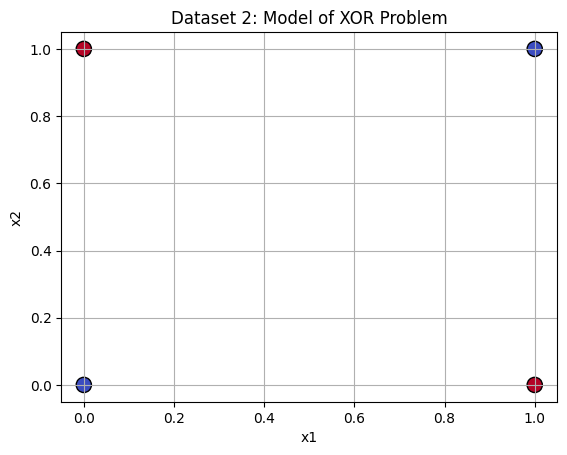

In [14]:
# Create the dataset
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_pm = np.array([-1, 1, 1, -1])

# Visualize the dataset
plt.scatter(X[:, 0], X[:, 1], c=y_pm, cmap="coolwarm", s=120, edgecolors="k")
plt.title("Dataset 2: Model of XOR Problem")
plt.xlabel("x1")
plt.ylabel("x2")
plt.grid(True)
plt.show()

Extra credit: Create a simple model that can be trained to solve XOR

epoch    0  loss=0.6935
epoch  500  loss=0.6840
epoch 1000  loss=0.3348
epoch 1500  loss=0.0463
epoch 2000  loss=0.0219
epoch 2500  loss=0.0141
epoch 3000  loss=0.0104
epoch 3500  loss=0.0082
epoch 4000  loss=0.0067
epoch 4500  loss=0.0057
Training loss: 0.004976229464382143
Training accuracy: 1.0
Probs: [0.00619235 0.9955205  0.99552471 0.00470729]


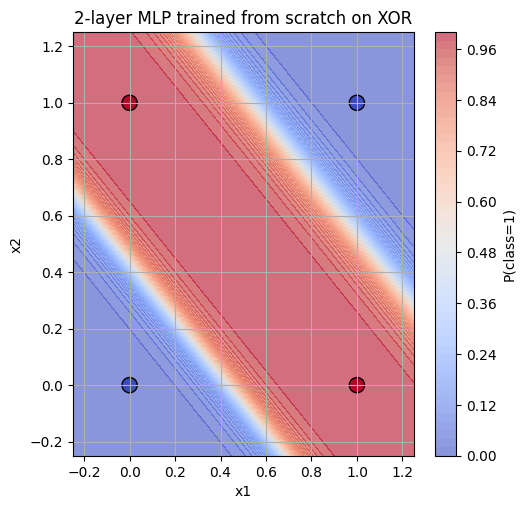

In [15]:
# Data
y = (y_pm == 1).astype(float).reshape(-1,1)  # shape (4,1)

# Helpers
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -(y * np.log(p) + (1 - y) * np.log(1 - p)).mean()

# Init params
rng = np.random.default_rng(0)
H = 2  # hidden units

W1 = rng.normal(scale=1.0, size=(H, 2))   # (2,2)
b1 = np.zeros((1, H))                     # (1,2)
W2 = rng.normal(scale=1.0, size=(H, 1))   # (2,1)
b2 = np.zeros((1, 1))                     # (1,1)

lr = 0.5
epochs = 5000

# Training loop
for epoch in range(epochs):
    # Forward
    z1 = X @ W1.T + b1         # (4,2)
    h  = sigmoid(z1)           # (4,2)
    z2 = h @ W2 + b2           # (4,1)
    p  = sigmoid(z2)           # (4,1)

    # Loss
    loss = bce_loss(y, p)

    # Backprop
    # dL/dz2 = p - y  (for BCE with sigmoid output)
    dz2 = (p - y)              # (4,1)
    dW2 = h.T @ dz2 / len(X)   # (2,1)
    db2 = dz2.mean(axis=0, keepdims=True)  # (1,1)

    # Hidden layer gradients
    dh  = dz2 @ W2.T           # (4,2)
    dz1 = dh * h * (1 - h)     # sigmoid'(z1)

    dW1 = dz1.T @ X / len(X)   # (2,2)
    db1 = dz1.mean(axis=0, keepdims=True)  # (1,2)

    # Update
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    # Print occasionally
    if epoch % 500 == 0:
      print(f"epoch {epoch:4d}  loss={loss:.4f}")

# Evaluate
z1 = X @ W1.T + b1
h  = sigmoid(z1)
z2 = h @ W2 + b2
p  = sigmoid(z2)
pred = (p >= 0.5).astype(int)
acc = (pred == y).mean()
print("Training loss:", float(bce_loss(y, p)))
print("Training accuracy:", acc)
print("Probs:", p.ravel())

# Plot decision regions
xx, yy = np.meshgrid(np.linspace(-0.25, 1.25, 300),
                     np.linspace(-0.25, 1.25, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
h_grid = sigmoid(grid @ W1.T + b1)
p_grid = sigmoid(h_grid @ W2 + b2).reshape(xx.shape)

plt.figure(figsize=(5.5,5.5))
cont = plt.contourf(xx, yy, p_grid, levels=50, cmap="coolwarm", alpha=0.6)
plt.colorbar(cont, label="P(class=1)")
plt.scatter(X[:,0], X[:,1], c=y_pm.ravel(), cmap="coolwarm", s=120, edgecolors="k")
plt.title("2-layer MLP trained from scratch on XOR")
plt.xlabel("x1"); plt.ylabel("x2"); plt.grid(True)
plt.xlim(-0.25, 1.25); plt.ylim(-0.25, 1.25)
plt.show()
